In [29]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ==========================================
# 1. 读取全量数据
# ==========================================
file_path = '/content/drive/MyDrive/Colab Notebooks/ECE 227/Project3/py/musicvideo3.csv'
# 使用所有数据，跳过表头
df = pd.read_csv(file_path, encoding_errors='ignore',
                 usecols=[2, 5, 6, 7], names=['title', 'publish_time', 'tags', 'views'], skiprows=1)

print(f"初始读取包含重复记录的数据量: {len(df)} 条。")

# ==========================================
# 2. 数据清洗、数值转换与【去重核心逻辑】
# ==========================================
# 关键：先将 views 转换为数值型。因为如果作为字符串排序，'999' 会大于 '10000'
df['views'] = pd.to_numeric(df['views'], errors='coerce')

# 去掉 views 为 NaN 或 tags 缺失的废数据
df = df.dropna(subset=['views', 'tags', 'title']).reset_index(drop=True)

# 【新增：去重逻辑】
# 按照 views 降序排列，然后按 title 去重，keep='first' 保证保留的是该视频打榜期间的“最高播放量”记录
df = df.sort_values('views', ascending=False).drop_duplicates(subset=['title'], keep='first').reset_index(drop=True)

print(f"==> 去重完成！当前全量唯一视频记录: {len(df)} 条。")

初始读取包含重复记录的数据量: 23957 条。
==> 去重完成！当前全量唯一视频记录: 2547 条。


已保存图片: 1_views_distribution_unique.png


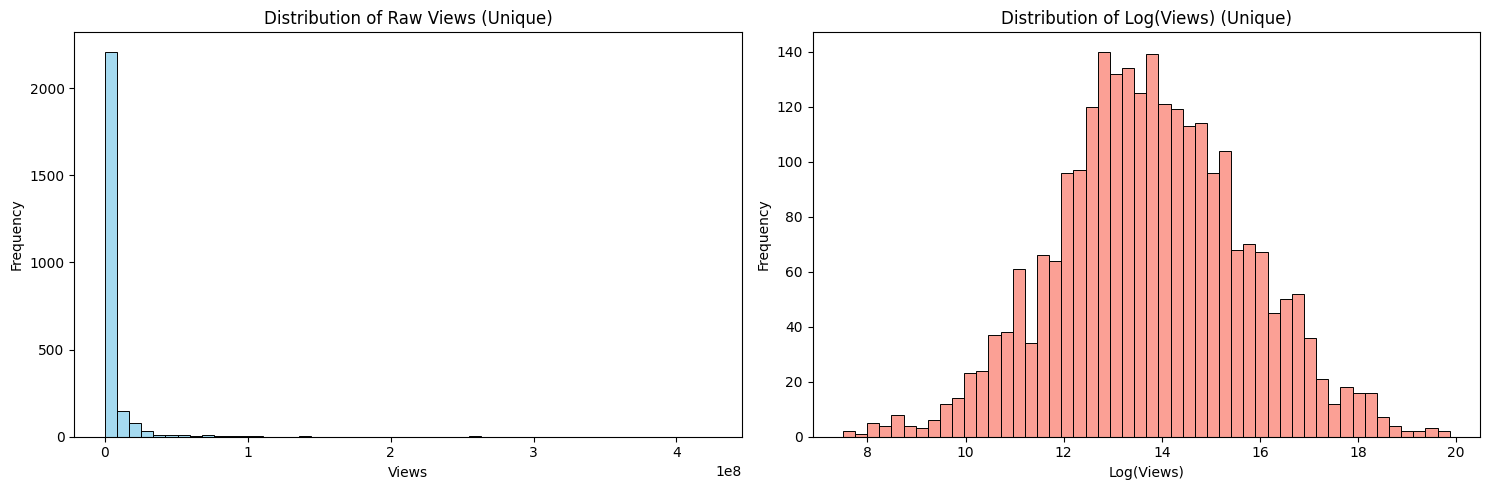

已保存图片: 2_tag_frequency_powerlaw_unique.png


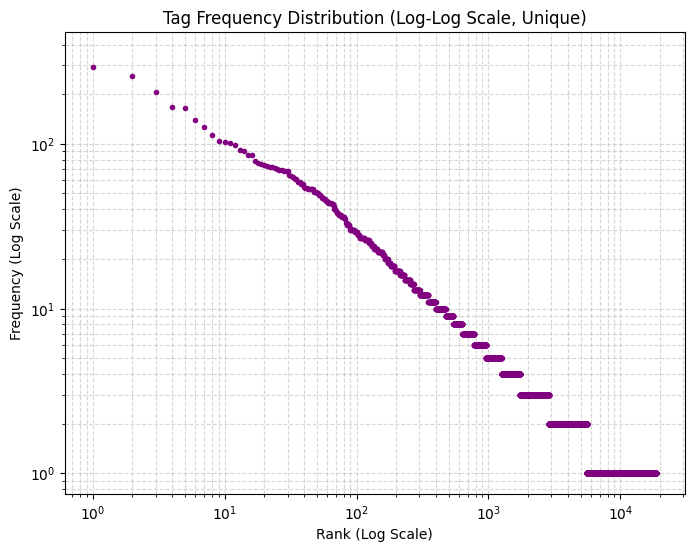

In [30]:
# ==========================================
# 3. 特征提取
# ==========================================
# 计算 log(views)
df['log_views'] = df['views'].apply(lambda x: math.log(x) if x > 0 else 0)
max_views = df['views'].max()

# 清洗 tags 列：去除多余的引号，并按 '|' 分割成列表
df['cleaned_tags'] = df['tags'].astype(str).str.replace('"', '').str.lower().str.split('|')

# ==========================================
# 4. 数据可视化 - 播放量分布
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 原始 Views 分布
sns.histplot(df['views'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Raw Views (Unique)')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Frequency')

# Log(Views) 分布
sns.histplot(df['log_views'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Log(Views) (Unique)')
axes[1].set_xlabel('Log(Views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('1_views_distribution_unique.png', dpi=300, bbox_inches='tight')
print("已保存图片: 1_views_distribution_unique.png")
plt.show()

# ==========================================
# 5. 数据可视化 - 验证幂律分布
# ==========================================
all_tags = [tag for sublist in df['cleaned_tags'] for tag in sublist if tag.strip() != '']
tag_counts = Counter(all_tags)
frequencies = sorted(list(tag_counts.values()), reverse=True)

plt.figure(figsize=(8, 6))
plt.plot(frequencies, marker='.', linestyle='none', color='purple')
plt.xscale('log')
plt.yscale('log')
plt.title('Tag Frequency Distribution (Log-Log Scale, Unique)')
plt.xlabel('Rank (Log Scale)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.savefig('2_tag_frequency_powerlaw_unique.png', dpi=300, bbox_inches='tight')
print("已保存图片: 2_tag_frequency_powerlaw_unique.png")
plt.show()

正在构建基于 log_views 的宏观网络，当前阈值 threshold = 0.015...
建图完成！耗时: 0.16 秒

--- 网络诊断信息 ---
节点总数: 2547
连边总数: 14279
网络密度: 0.004404 (一般在 0.001 - 0.05 之间比较适合社区发现)
总连通分量数量: 123
前 5 大连通分量的节点数: [1531, 196, 151, 94, 39]
==> 提取的最大连通分量 (LCC) 节点数: 1531 (占总数据 60.11%)

已保存图片: 3_macro_network_diagnostics.png


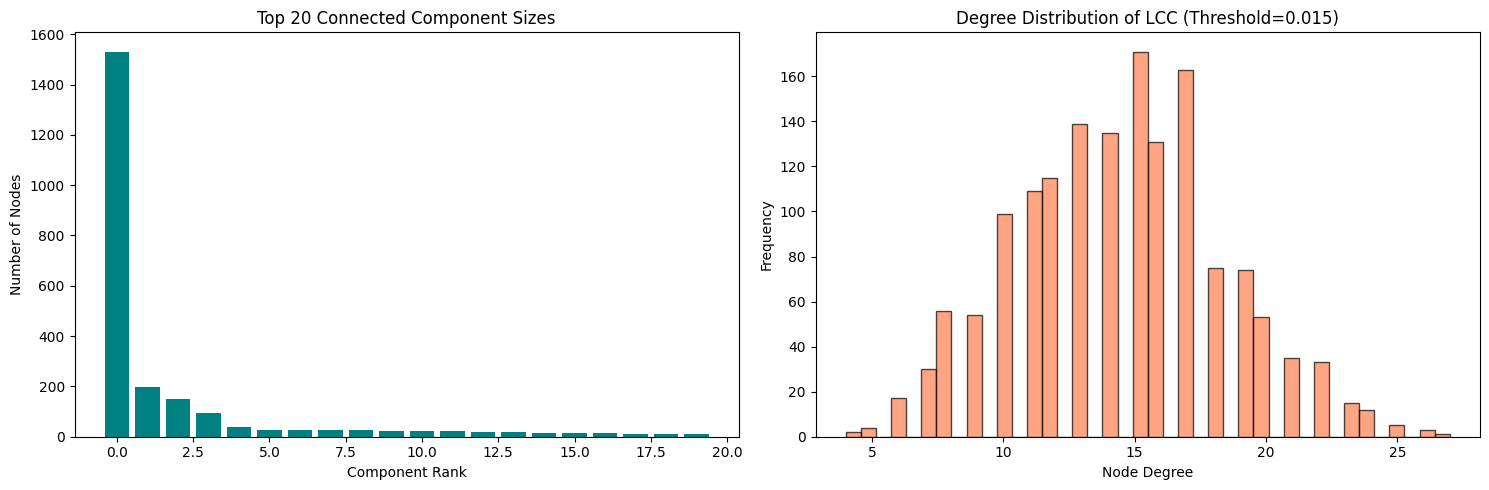

In [34]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 设定关键参数（基于 log_views 差值的阈值）
# ==========================================
threshold_views = 0.015

print(f"正在构建基于 log_views 的宏观网络，当前阈值 threshold = {threshold_views}...")
start_time = time.time()

# ==========================================
# 2. 构建网络图
# ==========================================
G_views = nx.Graph()

# 添加节点，并将有用的属性（标题、log播放量、清洗后的标签）存入节点中
for idx, row in df.iterrows():
    G_views.add_node(idx, title=row['title'], log_views=row['log_views'], tags=row['cleaned_tags'])

# 高效建边逻辑：按 log_views 排序，只和相近的视频比较，避免 O(N^2) 的双重循环
nodes_data = df[['log_views']].sort_values(by='log_views').reset_index()
node_indices = nodes_data['index'].values
log_views_vals = nodes_data['log_views'].values

edges_to_add = []
n = len(node_indices)
for i in range(n):
    u = node_indices[i]
    val_u = log_views_vals[i]
    # 只往后找，直到差值超过阈值
    for j in range(i + 1, n):
        v = node_indices[j]
        val_v = log_views_vals[j]
        if (val_v - val_u) <= threshold_views:
            edges_to_add.append((u, v))
        else:
            break  # 一旦超过阈值，因为是排好序的，后面的差值肯定更大，直接跳出内层循环

G_views.add_edges_from(edges_to_add)
print(f"建图完成！耗时: {time.time() - start_time:.2f} 秒")

# ==========================================
# 3. 网络诊断与连通分量分析
# ==========================================
num_nodes = G_views.number_of_nodes()
num_edges = G_views.number_of_edges()
density = nx.density(G_views)

print(f"\n--- 网络诊断信息 ---")
print(f"节点总数: {num_nodes}")
print(f"连边总数: {num_edges}")
print(f"网络密度: {density:.6f} (一般在 0.001 - 0.05 之间比较适合社区发现)")

# 获取所有的连通分量
components = list(nx.connected_components(G_views))
components_sizes = [len(c) for c in components]
components_sizes.sort(reverse=True)

print(f"总连通分量数量: {len(components)}")
print(f"前 5 大连通分量的节点数: {components_sizes[:5]}")

# 提取最大连通分量 (LCC)
lcc_nodes = max(components, key=len)
G_lcc = G_views.subgraph(lcc_nodes).copy()
print(f"==> 提取的最大连通分量 (LCC) 节点数: {G_lcc.number_of_nodes()} (占总数据 {G_lcc.number_of_nodes()/num_nodes*100:.2f}%)")

# ==========================================
# 4. 可视化评估与保存
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 图 A：连通分量大小分布 (看看网络有没有碎成太多块)
axes[0].bar(range(min(20, len(components_sizes))), components_sizes[:20], color='teal')
axes[0].set_title('Top 20 Connected Component Sizes')
axes[0].set_xlabel('Component Rank')
axes[0].set_ylabel('Number of Nodes')

# 图 B：最大连通分量(LCC)的度分布
degrees = [d for n, d in G_lcc.degree()]
axes[1].hist(degrees, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Degree Distribution of LCC (Threshold={threshold_views})')
axes[1].set_xlabel('Node Degree')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('3_macro_network_diagnostics.png', dpi=300, bbox_inches='tight')
print("\n已保存图片: 3_macro_network_diagnostics.png")
plt.show()

开始准备宏观网络可视化数据...
正在计算网络布局 (包含 2011 个节点)，请稍候...
布局计算完成！耗时: 15.85 秒

已保存图片: 4_macro_network_components.png


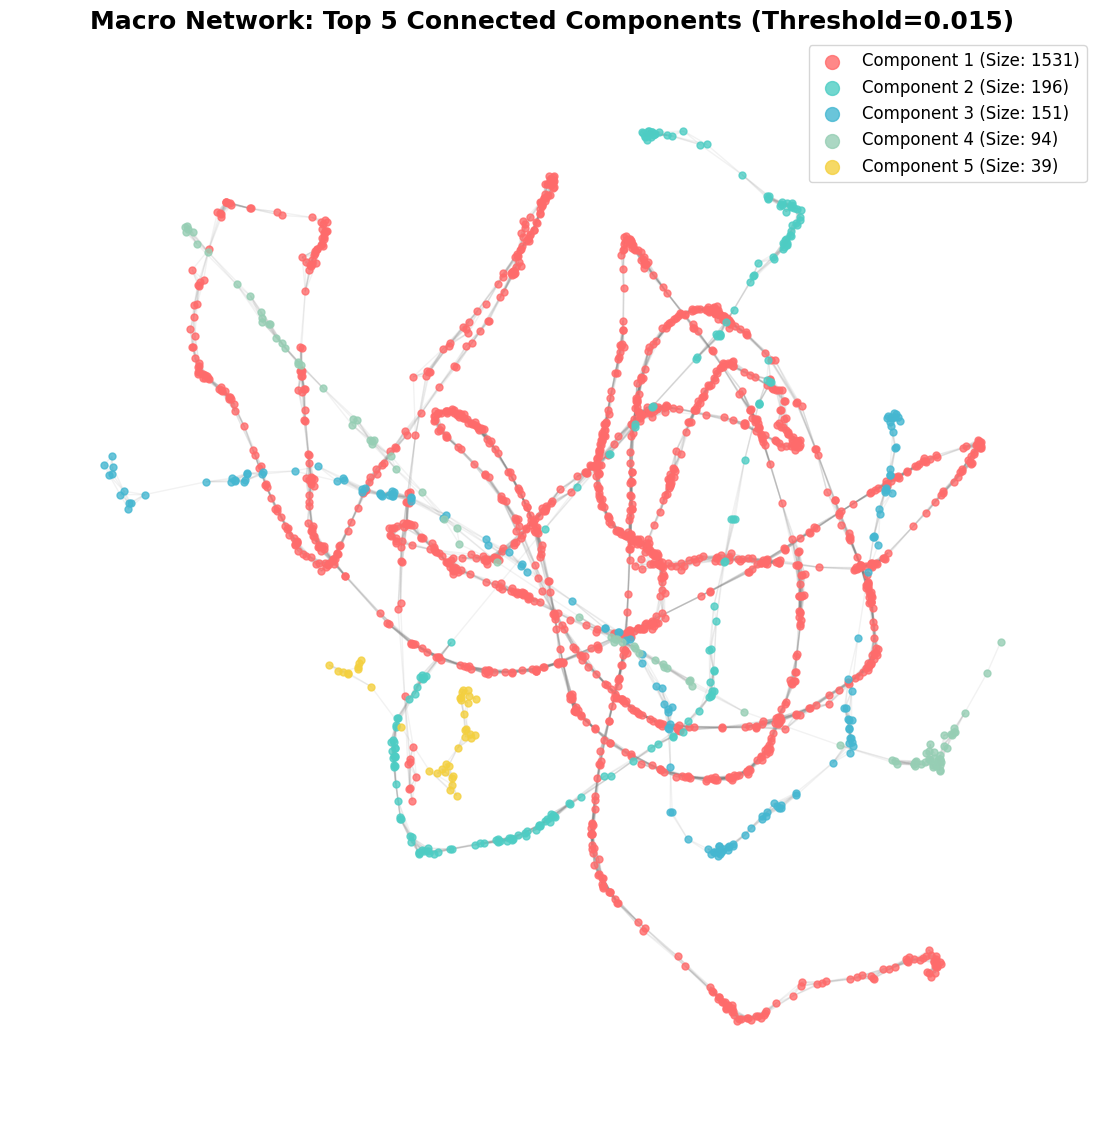

In [38]:
import networkx as nx
import matplotlib.pyplot as plt
import time

print("开始准备宏观网络可视化数据...")
start_time = time.time()

# 1. 提取前 5 大连通分量的节点集合
components = list(nx.connected_components(G_views))
components.sort(key=len, reverse=True)
top_5_components = components[:5]

# 构建一个只包含这前 5 大分量的子图
nodes_to_draw = set()
for comp in top_5_components:
    nodes_to_draw.update(comp)

G_top5 = G_views.subgraph(nodes_to_draw)

print(f"正在计算网络布局 (包含 {G_top5.number_of_nodes()} 个节点)，请稍候...")
# 2. 计算节点坐标 (适当调整了 k 值，让聚类之间推得更开)
pos = nx.spring_layout(G_top5, k=0.1, iterations=40, seed=42)
print(f"布局计算完成！耗时: {time.time() - start_time:.2f} 秒")

# 3. 开始绘图
plt.figure(figsize=(14, 14))

# 为前 5 个分量准备 5 种好看的颜色
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F4D03F']

# 循环画出每个分量的节点
for i, comp in enumerate(top_5_components):
    nx.draw_networkx_nodes(G_top5, pos,
                           nodelist=list(comp),
                           node_size=25,  # 稍微调大节点尺寸
                           node_color=colors[i],
                           alpha=0.8,
                           label=f'Component {i+1} (Size: {len(comp)})')

# 画出连边 (透明度设得很低，作为背景)
nx.draw_networkx_edges(G_top5, pos, alpha=0.1, edge_color='gray')

# 4. 图表装饰与保存
plt.title(f"Macro Network: Top 5 Connected Components (Threshold={threshold_views})", fontsize=18, fontweight='bold')
plt.legend(markerscale=2, fontsize=12, loc='upper right')
plt.axis('off')  # 隐藏坐标轴

# 保存图片为 4_名称 格式
plt.savefig('4_macro_network_components.png', dpi=300, bbox_inches='tight')
print("\n已保存图片: 4_macro_network_components.png")
plt.show()

正在 LCC (n=1531) 内部构建标签相似度网络, 阈值: 0.1...
建图完成！耗时: 5.06 秒

--- 内容网络诊断 (Jaccard >= 0.1) ---
节点数: 1531
连边数: 10757
孤立节点数: 296 (即没有任何视频与它有 10.0% 以上的标签重合)
平均聚类系数: 0.4997 (期望在 0.2 - 0.6 之间)

已保存图片: 5_jaccard_distribution.png


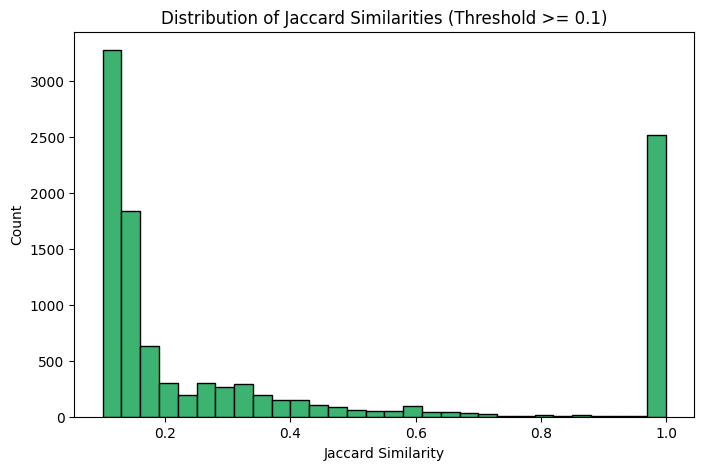

In [40]:
import networkx as nx
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 设定标签相似度阈值
# ==========================================
# 去重后，0.1 是一个比较合理的测试起点
threshold_jaccard = 0.1

print(f"正在 LCC (n={G_lcc.number_of_nodes()}) 内部构建标签相似度网络, 阈值: {threshold_jaccard}...")
start_time = time.time()

# 定义 Jaccard 相似度函数
def get_jaccard_sim(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    if not s1 or not s2: return 0
    return len(s1.intersection(s2)) / len(s1.union(s2))

# ==========================================
# 2. 构建精细内容网络 G_tags
# ==========================================
G_tags = nx.Graph()

# 导入 LCC 中的节点
lcc_node_list = list(G_lcc.nodes())
for n in lcc_node_list:
    G_tags.add_node(n, **G_lcc.nodes[n])

# 计算两两之间的相似度 (1531个节点，约117万次对比，很快就能跑完)
edges_to_add = []
node_data_list = [(n, G_lcc.nodes[n]['tags']) for n in lcc_node_list]

for i in range(len(node_data_list)):
    u, tags_u = node_data_list[i]
    for j in range(i + 1, len(node_data_list)):
        v, tags_v = node_data_list[j]

        sim = get_jaccard_sim(tags_u, tags_v)
        if sim >= threshold_jaccard:
            edges_to_add.append((u, v, sim))

G_tags.add_weighted_edges_from(edges_to_add)
print(f"建图完成！耗时: {time.time() - start_time:.2f} 秒")

# ==========================================
# 3. 精细网络诊断
# ==========================================
print(f"\n--- 内容网络诊断 (Jaccard >= {threshold_jaccard}) ---")
print(f"节点数: {G_tags.number_of_nodes()}")
print(f"连边数: {G_tags.number_of_edges()}")

isolates = list(nx.isolates(G_tags))
print(f"孤立节点数: {len(isolates)} (即没有任何视频与它有 {threshold_jaccard*100}% 以上的标签重合)")

# 计算平均聚类系数
avg_clustering = nx.average_clustering(G_tags)
print(f"平均聚类系数: {avg_clustering:.4f} (期望在 0.2 - 0.6 之间)")

# ==========================================
# 4. 可视化：保存 Jaccard 分布图
# ==========================================
plt.figure(figsize=(8, 5))
edge_weights = [d['weight'] for u, v, d in G_tags.edges(data=True)]

if len(edge_weights) > 0:
    plt.hist(edge_weights, bins=30, color='mediumseagreen', edgecolor='black')
    plt.title(f'Distribution of Jaccard Similarities (Threshold >= {threshold_jaccard})')
    plt.xlabel('Jaccard Similarity')
    plt.ylabel('Count')
else:
    plt.text(0.5, 0.5, 'No edges created', ha='center', va='center')

plt.savefig('5_jaccard_distribution.png', dpi=300, bbox_inches='tight')
print("\n已保存图片: 5_jaccard_distribution.png")
plt.show()

开始进行中心性分析与全网络可视化...
剔除孤立节点后，当前核心网络包含 1235 个节点。
正在计算度中心性 (Degree)...
正在计算介数中心性 (Betweenness) - 这可能需要十几秒...
正在计算特征向量中心性 (Eigenvector)...

--- Top 20% 中心性节点分析 ---
Top 20% 节点数量为: 247 个
同时具有极高 度中心性(Degree) 和 介数中心性(Betweenness) 的节点有: 60 个
重合率: 24.29%
Top 5 重合节点的标题示例:
 - Carrie Underwood - The Champion (Official Lyric Video) ft. Ludacris
 - MØ - When I Was Young (Official Video)
 - Ansel Elgort - Supernova
 - 6IX9INE Billy (WSHH Exclusive - Official Audio)
 - Sade - Flower of the Universe (From Disney's A Wrinkle in Time) (Official Lyric Video)

正在计算网络布局，请稍候...

可视化完成！总耗时: 11.94 秒
已保存图片: 6_micro_network_centrality.png


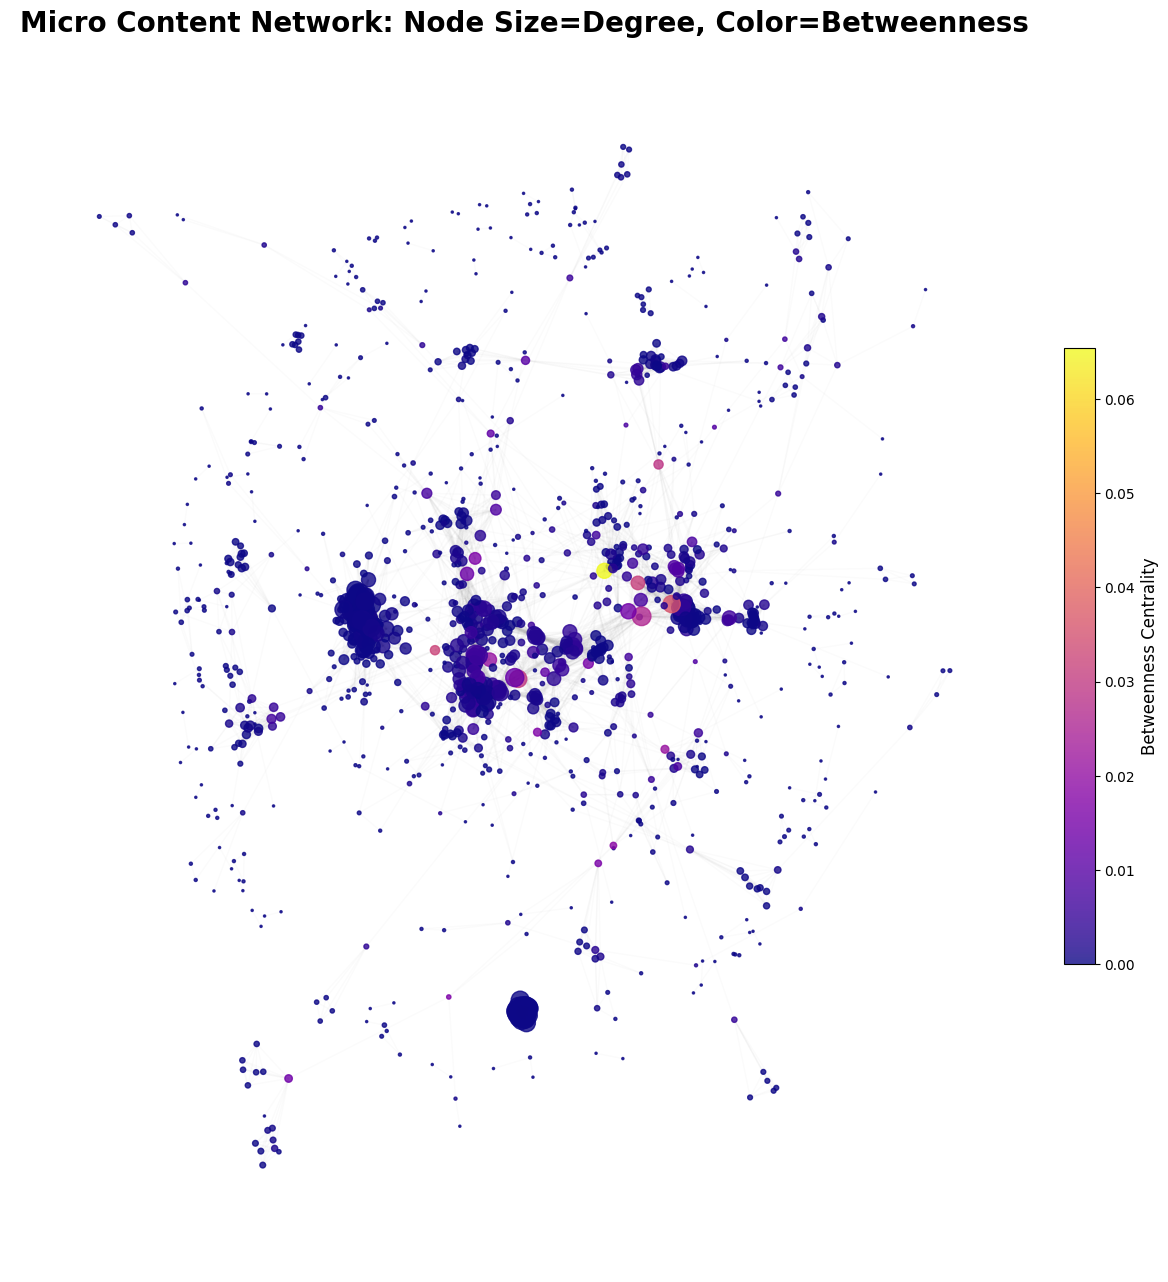

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import numpy as np

print("开始进行中心性分析与全网络可视化...")
start_time = time.time()

# ==========================================
# 1. 清理网络：剔除孤立节点
# ==========================================
G_core = G_tags.copy()
isolates = list(nx.isolates(G_core))
G_core.remove_nodes_from(isolates)
num_core_nodes = G_core.number_of_nodes()
print(f"剔除孤立节点后，当前核心网络包含 {num_core_nodes} 个节点。")

# ==========================================
# 2. 计算三大中心性指标
# ==========================================
print("正在计算度中心性 (Degree)...")
deg_cent = nx.degree_centrality(G_core)

print("正在计算介数中心性 (Betweenness) - 这可能需要十几秒...")
# 介数中心性计算量较大，但 1200 个节点在可接受范围内
bet_cent = nx.betweenness_centrality(G_core)

print("正在计算特征向量中心性 (Eigenvector)...")
eig_cent = nx.eigenvector_centrality(G_core, max_iter=1000)

# 将中心性属性保存回图中，方便后续社区分析使用
nx.set_node_attributes(G_core, deg_cent, 'degree_cent')
nx.set_node_attributes(G_core, bet_cent, 'betweenness_cent')
nx.set_node_attributes(G_core, eig_cent, 'eigenvector_cent')

# ==========================================
# 3. 回应项目要求：Top 20% 的节点重合度分析
# ==========================================
top_20_percent_count = int(num_core_nodes * 0.2)

# 按中心性值降序排列获取 Top 20% 的节点列表
top_deg = sorted(deg_cent, key=deg_cent.get, reverse=True)[:top_20_percent_count]
top_bet = sorted(bet_cent, key=bet_cent.get, reverse=True)[:top_20_percent_count]

# 取交集
overlap_nodes = set(top_deg).intersection(set(top_bet))
overlap_ratio = len(overlap_nodes) / top_20_percent_count * 100

print(f"\n--- Top 20% 中心性节点分析 ---")
print(f"Top 20% 节点数量为: {top_20_percent_count} 个")
print(f"同时具有极高 度中心性(Degree) 和 介数中心性(Betweenness) 的节点有: {len(overlap_nodes)} 个")
print(f"重合率: {overlap_ratio:.2f}%")
print("Top 5 重合节点的标题示例:")
for n in list(overlap_nodes)[:5]:
    print(f" - {G_core.nodes[n]['title']}")

# ==========================================
# 4. 微观网络全景可视化
# ==========================================
print("\n正在计算网络布局，请稍候...")
# 使用 spring_layout，k值稍微调大一点防止节点挤压
pos = nx.spring_layout(G_core, k=0.15, iterations=40, seed=42)

plt.figure(figsize=(16, 16))

# 节点大小映射到 度中心性 (放大系数让区分度更明显)
node_sizes = [deg_cent[n] * 3000 for n in G_core.nodes()]

# 节点颜色映射到 介数中心性 (高介数节点会显示为高亮颜色，它们是连接不同社区的桥梁)
node_colors = [bet_cent[n] for n in G_core.nodes()]

# 画边
nx.draw_networkx_edges(G_core, pos, alpha=0.03, edge_color='gray')

# 画节点
nodes = nx.draw_networkx_nodes(G_core, pos,
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=plt.cm.plasma, # 使用 plasma 颜色映射
                               alpha=0.8)

# 添加颜色条
cbar = plt.colorbar(nodes, shrink=0.5, pad=0.02)
cbar.set_label('Betweenness Centrality', fontsize=12)

plt.title("Micro Content Network: Node Size=Degree, Color=Betweenness", fontsize=20, fontweight='bold')
plt.axis('off')

plt.savefig('6_micro_network_centrality.png', dpi=300, bbox_inches='tight')
print(f"\n可视化完成！总耗时: {time.time() - start_time:.2f} 秒")
print("已保存图片: 6_micro_network_centrality.png")
plt.show()

正在运行 Louvain 社区发现算法...
Louvain 算法划分完成！总共发现了 102 个社区。
 - 准备处理 社区 1 (包含节点数: 271)
 - 准备处理 社区 2 (包含节点数: 161)

正在生成高清词云，请稍候...
已保存图片: 7_Cluster_1_YouTube_WordCloud.png


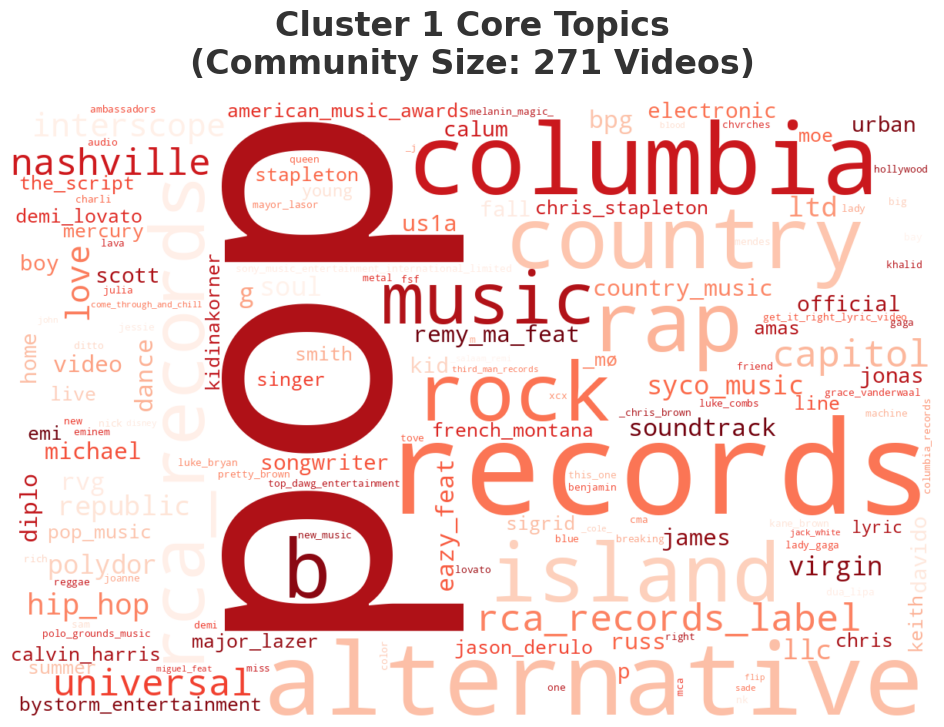

已保存图片: 7_Cluster_2_YouTube_WordCloud.png


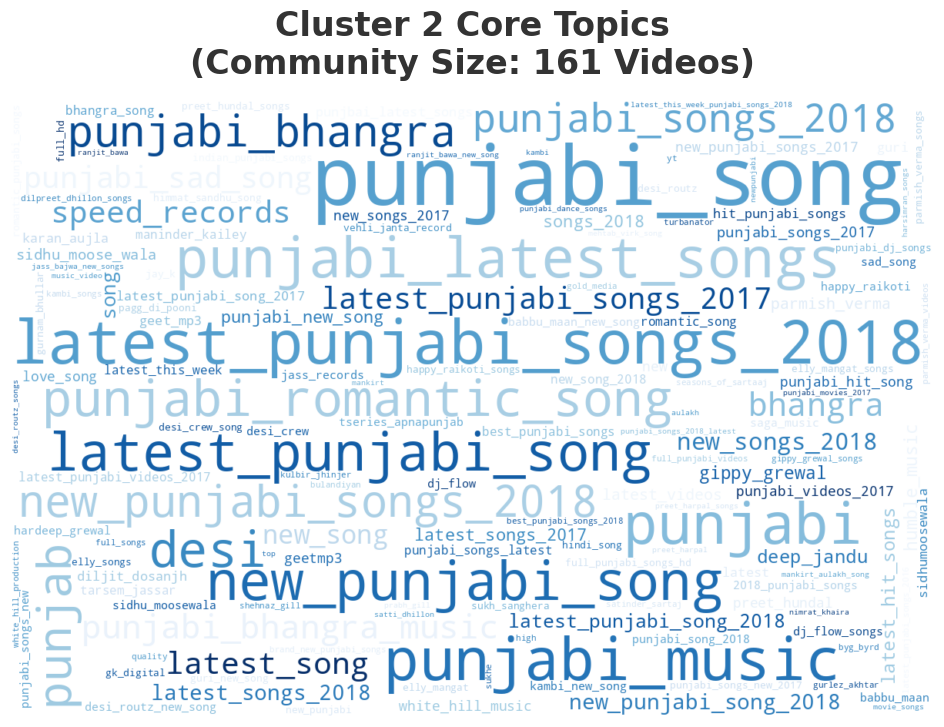


全部完成！总耗时: 7.78 秒


In [51]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from PIL import Image
import time
import os

print("正在运行 Louvain 社区发现算法...")
start_time = time.time()

# ==========================================
# 1. 社区发现 (Louvain 算法)
# ==========================================
communities = nx_comm.louvain_communities(G_core, weight='weight', resolution=1.0)
# 按社区大小降序排列
communities = sorted(communities, key=len, reverse=True)

print(f"Louvain 算法划分完成！总共发现了 {len(communities)} 个社区。")

# ==========================================
# 2. 提取 Top 2 社区的标签数据
# ==========================================
num_top_communities = min(2, len(communities))
community_tags_text = []

for i in range(num_top_communities):
    comp_nodes = list(communities[i])
    print(f" - 准备处理 社区 {i+1} (包含节点数: {len(comp_nodes)})")

    all_tags_in_comp = []
    for n in comp_nodes:
        all_tags_in_comp.extend(G_core.nodes[n]['tags'])

    # 拼接文本，将空格替换为下划线防止词组被拆散，过滤极短词汇
    text = " ".join([tag.replace(" ", "_") for tag in all_tags_in_comp if len(tag) > 2])
    community_tags_text.append(text)

# ==========================================
# 3. 加载 YouTube 图标蒙版 (Mask)
# ==========================================
# mask_path = 'WordCloud.png' # 请确保文件名和路径正确，如果在Drive里请写全路径
# yt_mask = None

# if os.path.exists(mask_path):
#     print(f"成功找到蒙版图片: {mask_path}")
#     yt_mask = np.array(Image.open(mask_path))
# else:
#     print(f"⚠️ 警告: 未找到蒙版图片 {mask_path}，将使用默认矩形形状。请检查路径！")

# ==========================================
# 4. 生成幻灯片级别的高清独立词云
# ==========================================
print("\n正在生成高清词云，请稍候...")

# 为两个社区设定不同的配色，方便在 Slides 中对比
# 社区 1 用红色系 (YouTube 主色调)，社区 2 用蓝色系
colormaps = ['Reds', 'Blues']

for i in range(num_top_communities):
    # 配置 WordCloud，加入蒙版和轮廓
    wc = WordCloud(background_color='white',
                   mask=yt_mask,
                   colormap=colormaps[i],
                   contour_width=2 if yt_mask is not None else 0, # 如果有蒙版，加上边缘轮廓线
                   contour_color='firebrick' if i==0 else 'navy', # 轮廓颜色
                   collocations=False,
                   max_words=150,
                   width=1200, height=800).generate(community_tags_text[i])

    # 创建独立的大图，非常适合直接复制进 PPT/Slides
    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation='bilinear')

    # 标题格式优化，更像数据报告
    plt.title(f'Cluster {i+1} Core Topics\n(Community Size: {len(communities[i])} Videos)',
              fontsize=24, fontweight='bold', pad=20, color='#333333')
    plt.axis('off')

    # 保存图片为独立文件
    output_filename = f'7_Cluster_{i+1}_YouTube_WordCloud.png'
    plt.savefig(output_filename, dpi=300, transparent=False, bbox_inches='tight')
    print(f"已保存图片: {output_filename}")
    plt.show()

print(f"\n全部完成！总耗时: {time.time() - start_time:.2f} 秒")

In [52]:
import networkx as nx
import time

print("正在计算网络直径与平均最短路径...")
start_time = time.time()

# 提取 G_core 中的最大连通分量，因为最短路径只能在完全连通的图里算
components = list(nx.connected_components(G_core))
G_core_lcc = G_core.subgraph(max(components, key=len))

print(f"用于计算的核心连通子图包含 {G_core_lcc.number_of_nodes()} 个节点。")

# 计算平均最短路径
avg_path_length = nx.average_shortest_path_length(G_core_lcc)
print(f"--> 平均最短路径 (Average Shortest Path): {avg_path_length:.4f}")

# 计算网络直径
diameter = nx.diameter(G_core_lcc)
print(f"--> 网络直径 (Diameter): {diameter}")

print(f"\n计算完成！耗时: {time.time() - start_time:.2f} 秒")

正在计算网络直径与平均最短路径...
用于计算的核心连通子图包含 716 个节点。
--> 平均最短路径 (Average Shortest Path): 4.8596
--> 网络直径 (Diameter): 14

计算完成！耗时: 9.36 秒
